## 패키지 로드 및 데이터 불러오기

In [22]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np


from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

from kneed import KneeLocator

from scipy.stats import normaltest

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_samples, silhouette_score
my_dpi = 200


In [23]:
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

my_dpi = 200


In [1]:
origin = load_data('east_west_airlines')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

항공사의 상용 고객 프로그램에 속한 승객에 대한 정보(마일리지 내역 및 적립 방식 등)를 담고 있는 데이터셋 (출처: https://www.kaggle.com/datasets/singhnproud77/eastwestairlines-heirarchical-clustering)

컬럼명             의미
-----------------  ------------------------------------------------
ID                 고객 고유 식별자
Balance            현재 마일리지 잔액
Qual_miles         최근 1년간 자격 마일리지 (등급 산정용)
cc1_miles          신용카드 유형 1 사용 마일리지 수준 (범주형: 0~5)
cc2_miles          신용카드 유형 2 사용 마일리지 수준 (범주형: 0~5)
cc3_miles          신용카드 유형 3 사용 마일리지 수준 (범주형: 0~5)
Bonus_miles        보너스 마일리지 총합
Bonus_trans        보너스 마일리지 적립 거래 횟수
Flight_miles_12mo  최근 12개월 비행 마일리지
Flight_trans_12    최근 12개월 비행 횟수
Days_since_enroll  프로그램 가입 후 경과 일수
Award              보상(마일리지/혜택) 사용 여부 (0=미사용, 1=사용)


===== 데이터 크기 확인 =====
데이터셋 크기: (3999, 12)
열 개수: 12
행 개수: 3999

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----


,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


# 데이터 탐색 및 전처리

### 카테고리 및 인덱스 지정

In [3]:
# 데이터 타입 변환
df = origin.astype(
    {
        "cc1_miles": "category",
        "cc2_miles": "category",
        "cc3_miles": "category",
        "Award": "category",
    }
)

# ID를 인덱스로 설정
df.set_index("ID", inplace=True)

# 데이터 정보 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3999 entries, 1 to 4021
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Balance            3999 non-null   int64   
 1   Qual_miles         3999 non-null   int64   
 2   cc1_miles          3999 non-null   category
 3   cc2_miles          3999 non-null   category
 4   cc3_miles          3999 non-null   category
 5   Bonus_miles        3999 non-null   int64   
 6   Bonus_trans        3999 non-null   int64   
 7   Flight_miles_12mo  3999 non-null   int64   
 8   Flight_trans_12    3999 non-null   int64   
 9   Days_since_enroll  3999 non-null   int64   
 10  Award              3999 non-null   category
dtypes: category(4), int64(7)
memory usage: 266.2 KB


### 결측치 처리

In [4]:
df.isna().sum()

Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award                0
dtype: int64

### 숫자형 칼럼 이름만 추출

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols

Index(['Balance', 'Qual_miles', 'Bonus_miles', 'Bonus_trans',
       'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll'],
      dtype='object')

### 정규성 검사

In [9]:
for f in num_cols:

    # 정규성 검정
    stat, p = normaltest(df[f])
    alpha = 0.05

    print(f"\n==== {f} 정규성 검정 ====")
    print(f"stat = {stat}, p = {p}")

    if p > alpha:
        print(f"{f}는 정규분포를 따릅니다 (귀무가설 채택)")
    else:
        print(f"{f}는 정규분포를 따르지 않습니다 (귀무가설 기각)")



==== Balance 정규성 검정 ====
stat = 4124.2072535023335, p = 0.0
Balance는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Qual_miles 정규성 검정 ====
stat = 5258.1689927621155, p = 0.0
Qual_miles는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Bonus_miles 정규성 검정 ====
stat = 2549.4521767492715, p = 0.0
Bonus_miles는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Bonus_trans 정규성 검정 ====
stat = 850.9866510065858, p = 1.6240397216842507e-185
Bonus_trans는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Flight_miles_12mo 정규성 검정 ====
stat = 5350.852777339507, p = 0.0
Flight_miles_12mo는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Flight_trans_12 정규성 검정 ====
stat = 4324.041619813923, p = 0.0
Flight_trans_12는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Days_since_enroll 정규성 검정 ====
stat = 771.5472879496165, p = 2.888252500678116e-168
Days_since_enroll는 정규분포를 따르지 않습니다 (귀무가설 기각)


### 정규분포를 따르지 않는 데이터에 대해서 표준화 적용

In [16]:
scale_df = df[num_cols].copy()
scaler = StandardScaler()
sdf = DataFrame(
    scaler.fit_transform(scale_df), columns=scale_df.columns, index=scale_df.index
)

sdf.head()

,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
ID,,,,,,,
1,-0.451141,-0.186299,-0.702786,-1.104065,-0.328603,-0.362168,1.395454
2,-0.539457,-0.186299,-0.701088,-0.999926,-0.328603,-0.362168,1.379957
3,-0.320031,-0.186299,-0.539253,-0.791649,-0.328603,-0.362168,1.411920
4,-0.583799,-0.186299,-0.689286,-1.104065,-0.328603,-0.362168,1.372208
5,0.239678,-0.186299,1.083121,1.499394,1.154932,0.692490,1.363975


### 카테고리 타입 변수명 추출


In [18]:
category_cols = df.select_dtypes(include=["category"]).columns
category_cols

Index(['cc1_miles', 'cc2_miles', 'cc3_miles', 'Award'], dtype='object')

### 정규화 결과에 카테고리 타입 변수 덧붙임

In [20]:
for c in category_cols:
    sdf[c] = df[c]

sdf.head()

,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,cc1_miles,cc2_miles,cc3_miles,Award
ID,,,,,,,,,,,
1,-0.451141,-0.186299,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,1,1,1,0
2,-0.539457,-0.186299,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,1,1,1,0
3,-0.320031,-0.186299,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,1,1,1,0
4,-0.583799,-0.186299,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,1,1,1,0
5,0.239678,-0.186299,1.083121,1.499394,1.154932,0.692490,1.363975,4,1,1,1


### 명목형 변수 인코딩

In [25]:
df_dummies = get_dummies(sdf, columns=category_cols, drop_first=False, dtype="int")
df_dummies.head()

,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,cc1_miles_1,cc1_miles_2,cc1_miles_3,...,cc2_miles_1,cc2_miles_2,cc2_miles_3,cc3_miles_1,cc3_miles_2,cc3_miles_3,cc3_miles_4,cc3_miles_5,Award_0,Award_1
ID,,,,,,,,,,,,,,,,,,,,,
1,-0.451141,-0.186299,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,1,0,0,...,1,0,0,1,0,0,0,0,1,0
2,-0.539457,-0.186299,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,1,0,0,...,1,0,0,1,0,0,0,0,1,0
3,-0.320031,-0.186299,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,1,0,0,...,1,0,0,1,0,0,0,0,1,0
4,-0.583799,-0.186299,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,1,0,0,...,1,0,0,1,0,0,0,0,1,0
5,0.239678,-0.186299,1.083121,1.499394,1.154932,0.692490,1.363975,0,0,0,...,1,0,0,1,0,0,0,0,0,1


# 엘보우 포인트 구하기

### 적절한 범위 내에서 이너셔 값 생성

In [26]:
klist = list(range(3,11))
inertia = []

for k in klist:
    estimator = KMeans(n_clusters=k, random_state=52)
    estimator.fit(X=df_dummies)
    inertia.append(estimator.inertia_)

inertia

[21681.21146287238,
 19050.243059779557,
 17223.662753945748,
 16147.215877762093,
 14559.901224522886,
 13406.937237651724,
 12605.903733292984,
 12102.292192843099]

### 최적의 k값(엘보우 포인트) 도출

In [29]:
kl = KneeLocator(klist, inertia, curve="convex", direction="decreasing", S=0.1)
best_k = kl.elbow
best_y = kl.elbow_y
print("found elbow", best_k)
print("found y:", best_y)

found elbow 5
found y: 17223.662753945748


### 시각화 확인

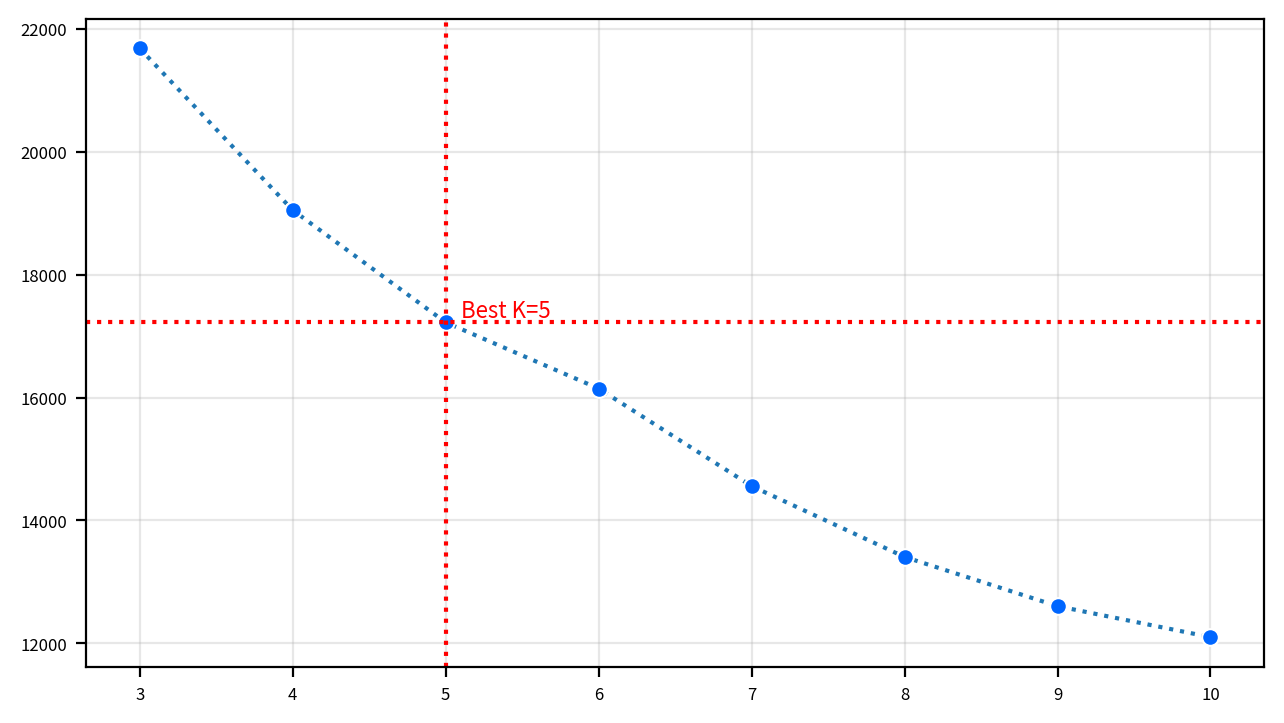

In [30]:
# -------------------------------
# 그래프 초기화
# -------------------------------
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=figsize,
    dpi=my_dpi
)


# -------------------------------
# Line Plot
# -------------------------------
sb.lineplot(
    x=klist,
    y=inertia,
    linestyle=":",
    marker="o",
    markerfacecolor="#0066ff",
    markeredgecolor="#ffffff"
)


# -------------------------------
# 엘보우 포인트 표시
# -------------------------------
if best_k is not None:

    ax.axvline(
        x=best_k,
        color="red",
        linestyle=":"
    )

    ax.axhline(
        y=best_y,
        color="red",
        linestyle=":"
    )

    ax.text(
        best_k + 0.1,
        best_y + 0.1,
        f"Best K={best_k}",
        fontsize=8,
        ha="left",
        va="bottom",
        color="r"
    )


# -------------------------------
# 그래프 옵션 및 출력
# -------------------------------
ax.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
plt.close()


In [33]:
# 시각화용 최소 군집 수 (분석 구간으로 결정)
klist = list(range(3, 11))

# 실루엣 스코어 저장 리스트
silhouette = []

for k in klist:
    estimator = KMeans(
        n_clusters=k,
        random_state=52
    )

    estimator.fit(X=df_dummies)

    cluster = estimator.predict(X=df_dummies)

    s_score = silhouette_score(
        X=df_dummies,
        labels=cluster
    )

    silhouette.append(s_score)

    # 실루엣 시각화가 필요할 경우 사용
    # visualize_silhouette(estimator=estimator, X_features=df_encoded)


# 결과 DataFrame 생성
silhouette_df = DataFrame(
    {
        "k": klist,
        "silhouette_score": silhouette
    }
)

silhouette_df


,k,silhouette_score
0,3,0.263705
1,4,0.275672
2,5,0.196063
3,6,0.200103
4,7,0.212934
5,8,0.219366
6,9,0.218425
7,10,0.219767


In [35]:
# -------------------------------
# KMeans 학습 및 클러스터 할당
# -------------------------------
estimator = KMeans(
    n_clusters=best_k,
    random_state=52
)

estimator.fit(X=df_dummies)
clusters = estimator.predict(df_dummies)

cdf = df_dummies.copy()
cdf["ClusterID"] = clusters

cdf.head()


,Balance,Qual_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,cc1_miles_1,cc1_miles_2,cc1_miles_3,...,cc2_miles_2,cc2_miles_3,cc3_miles_1,cc3_miles_2,cc3_miles_3,cc3_miles_4,cc3_miles_5,Award_0,Award_1,ClusterID
ID,,,,,,,,,,,,,,,,,,,,,
1,-0.451141,-0.186299,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,1,0,0,...,0,0,1,0,0,0,0,1,0,1
2,-0.539457,-0.186299,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,1,0,0,...,0,0,1,0,0,0,0,1,0,1
3,-0.320031,-0.186299,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,1,0,0,...,0,0,1,0,0,0,0,1,0,1
4,-0.583799,-0.186299,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,1,0,0,...,0,0,1,0,0,0,0,1,0,1
5,0.239678,-0.186299,1.083121,1.499394,1.154932,0.692490,1.363975,0,0,0,...,0,0,1,0,0,0,0,0,1,2


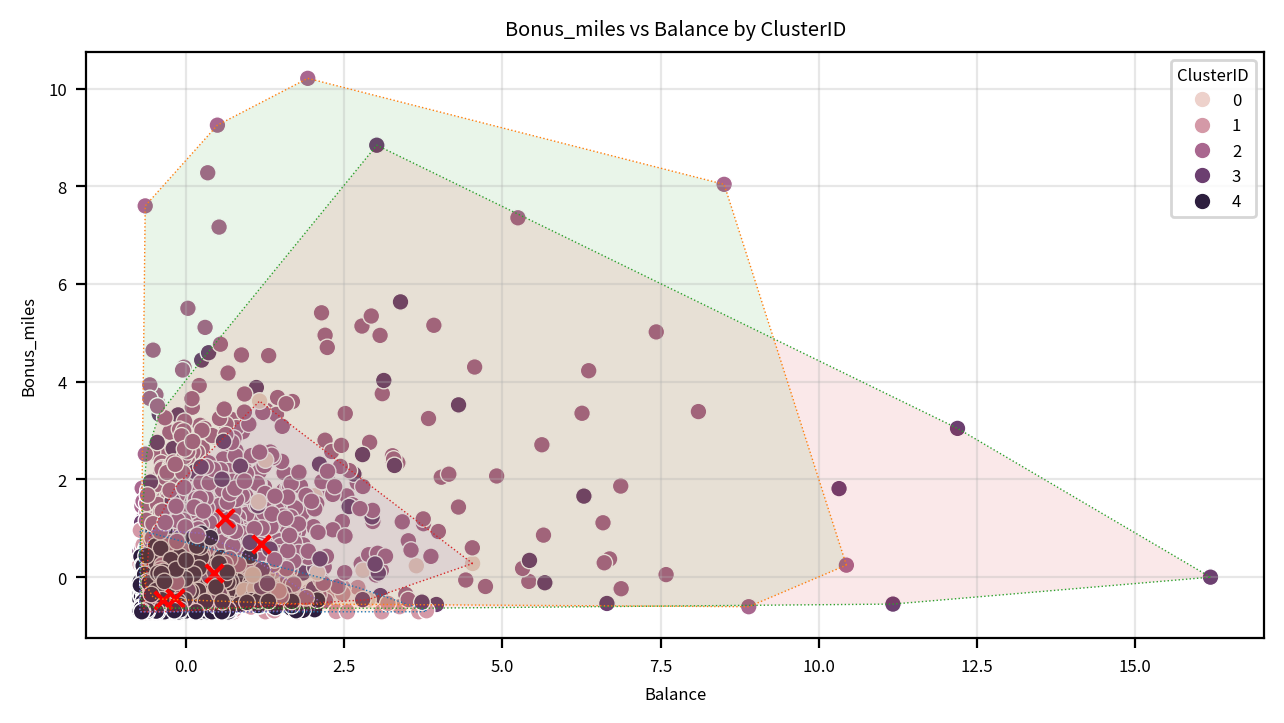

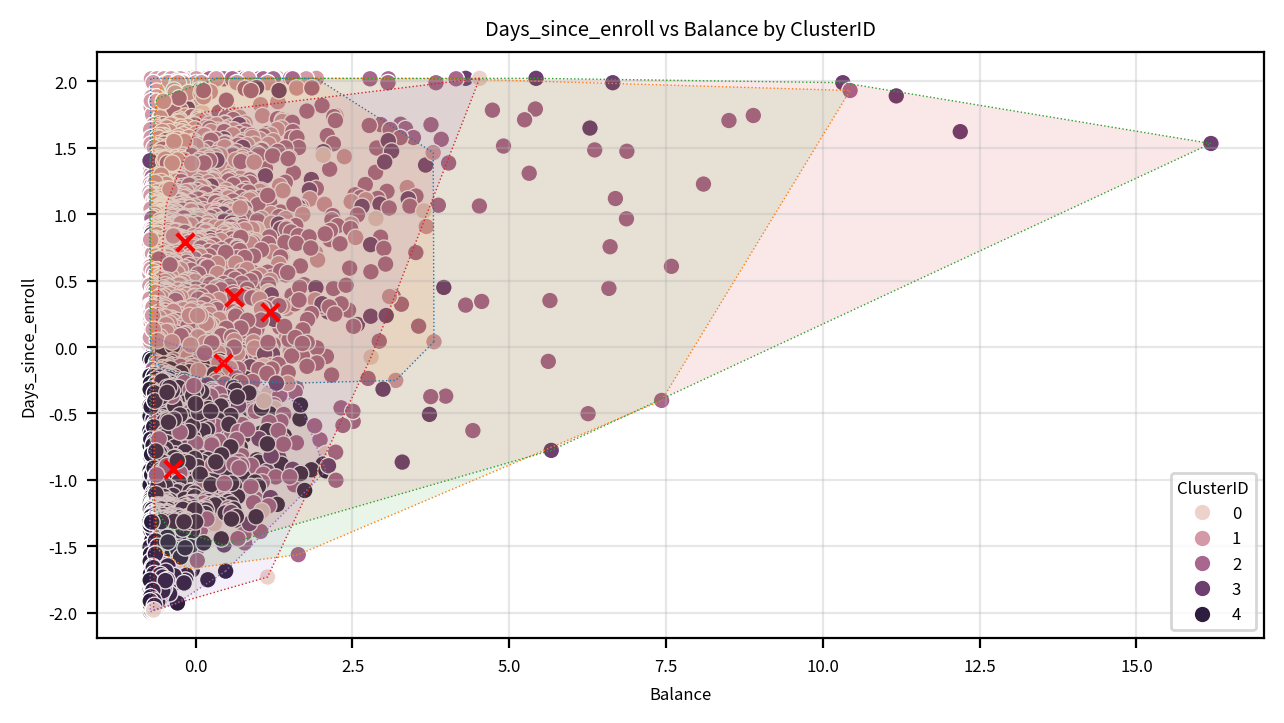

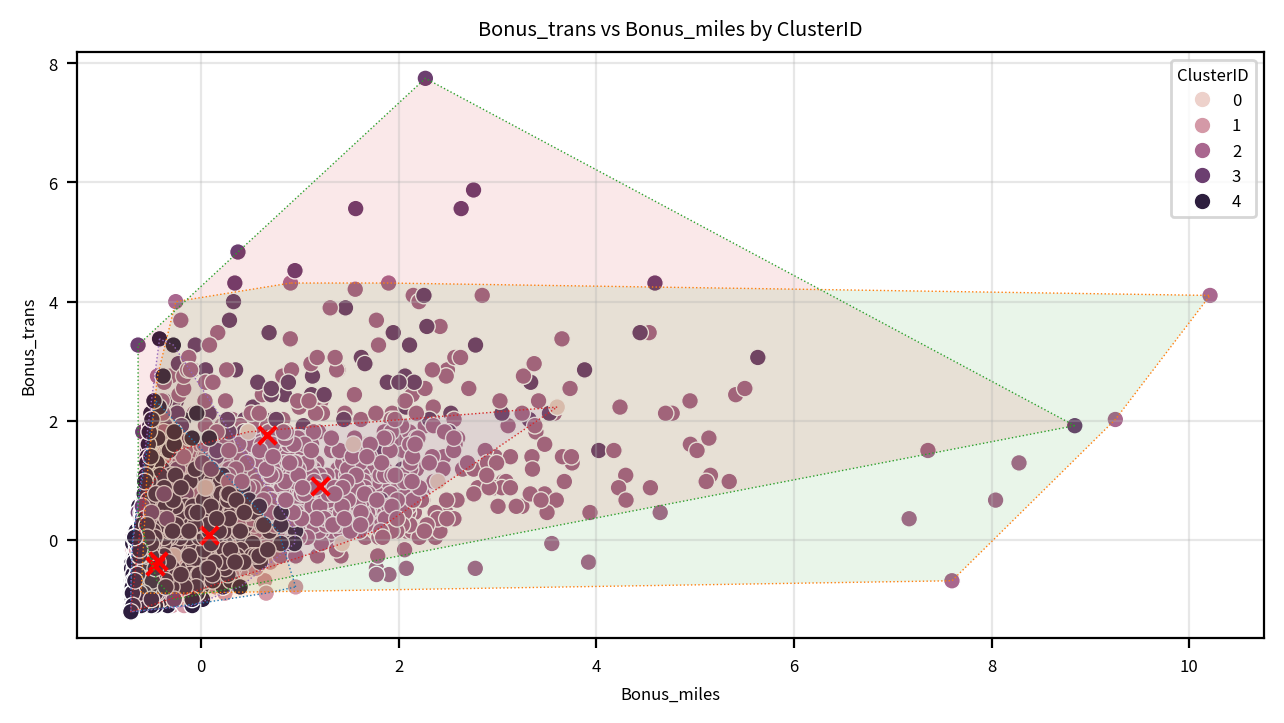

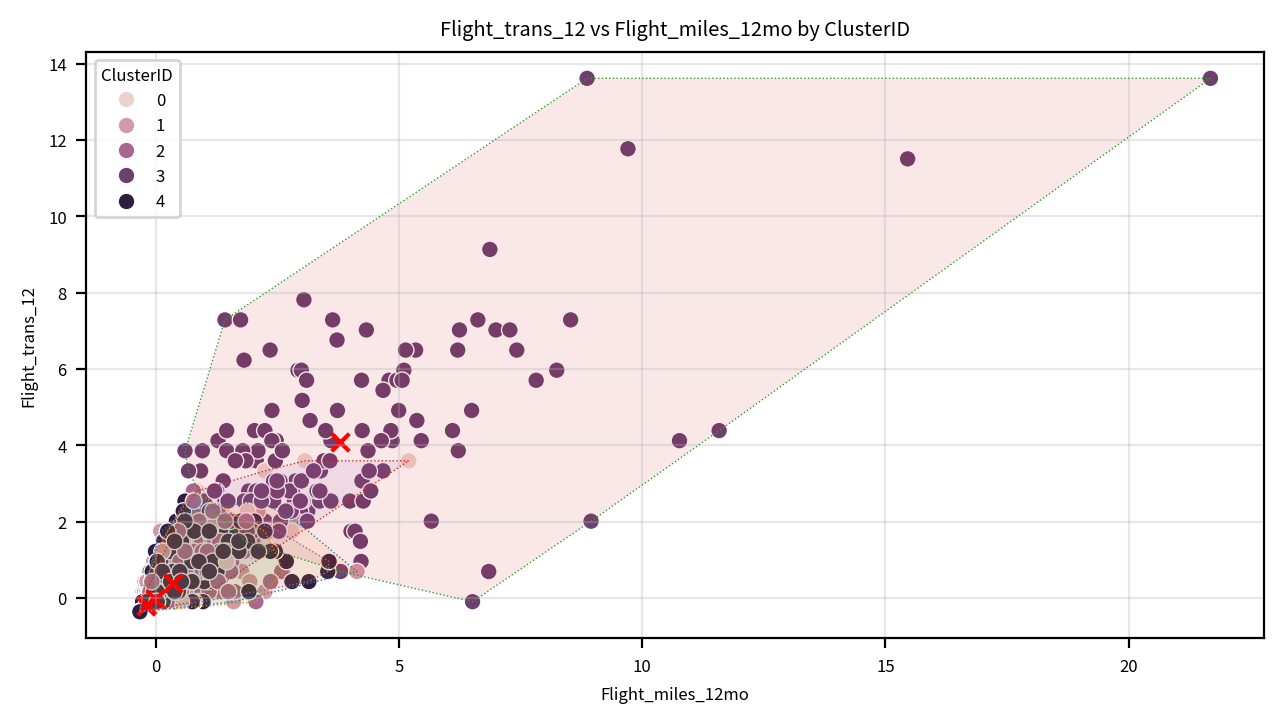

In [36]:
# -------------------------------
# 비교할 변수 쌍 정의
# -------------------------------
vs_fields = [
    # 혜택 마일리지 + 지출액 변수
    ["Balance", "Bonus_miles"],

    # 잔여 마일리지 + 가입 후 경과 일수
    ["Balance", "Days_since_enroll"],

    # 보너스 마일리지 + 거래 횟수
    ["Bonus_miles", "Bonus_trans"],

    # 비행 마일리지 + 거래 횟수
    ["Flight_miles_12mo", "Flight_trans_12"]
]


# -------------------------------
# 변수 쌍별 시각화
# -------------------------------
for f1, f2 in vs_fields:

    vdf = cdf.copy()

    hue_field = "ClusterID"
    x_field = f1
    y_field = f2

    x_field_index = vdf.columns.get_loc(x_field)
    y_field_index = vdf.columns.get_loc(y_field)

    # -------------------------------
    # 그래프 초기화
    # -------------------------------
    figsize = (1280 / my_dpi, 720 / my_dpi)
    fig, ax = plt.subplots(
        nrows=1,
        ncols=1,
        figsize=figsize,
        dpi=my_dpi
    )

    # -------------------------------
    # 데이터 산점도
    # -------------------------------
    sb.scatterplot(
        data=vdf,
        x=x_field,
        y=y_field,
        hue=hue_field
    )

    # -------------------------------
    # 군집별 Convex Hull
    # -------------------------------
    for c in vdf[hue_field].unique():

        # 군집별 데이터 분리
        df_c = vdf.loc[
            vdf[hue_field] == c,
            [x_field, y_field]
        ]

        try:
            # 외곽선 계산
            hull = ConvexHull(df_c)

            # 마지막 점과 첫 점 연결
            points = np.append(
                hull.vertices,
                hull.vertices[0]
            )

            # 외곽선
            ax.plot(
                df_c.iloc[points, 0],
                df_c.iloc[points, 1],
                linewidth=0.5,
                linestyle=":"
            )

            # 영역 채우기
            ax.fill(
                df_c.iloc[points, 0],
                df_c.iloc[points, 1],
                alpha=0.1
            )

        except Exception:
            pass

    # -------------------------------
    # 군집 중심점 표시
    # -------------------------------
    ax.scatter(
        estimator.cluster_centers_[:, x_field_index],
        estimator.cluster_centers_[:, y_field_index],
        marker="x",
        c="red",
        alpha=1,
        s=40
    )

    # -------------------------------
    # 그래프 옵션 및 출력
    # -------------------------------
    ax.set_title(f"{y_field} vs {x_field} by {hue_field}")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()
